# `harmonic_ud_grade` vs `ud_grade`: A Focused Comparison

When working with HEALPix maps, it is often necessary to change the
resolution — for example, to downgrade a high-resolution observation
map to a lower Nside for comparison with a model, or to reduce
computational cost for large-scale analyses.

healpy provides two functions for this:

- **`ud_grade`**: operates purely in **pixel space** by averaging
  groups of sub-pixels. It is fast, but because it does not apply any
  anti-aliasing filter, high-multipole power from the input grid
  "folds" back into the output — a phenomenon known as
  [aliasing](https://en.wikipedia.org/wiki/Aliasing).

- **`harmonic_ud_grade`**: operates in **spherical-harmonic space**.
  It decomposes the input map into $a_{\ell m}$ coefficients, applies
  the pixel-window correction following the prescription in
  [Planck 2015 XVI Eq. 1](https://arxiv.org/abs/1502.01587), and
  optionally scales the beam. Because the harmonic transform
  naturally band-limits the output, aliasing is eliminated.

## How `harmonic_ud_grade` works

The function implements the following per-$\ell$ transfer
([Planck 2015 XVI Eq. 1](https://arxiv.org/abs/1502.01587)):

$$
a^{\rm out}_{\ell m}
= \frac{p^{\rm out}_\ell}{p^{\rm in}_\ell}
  \cdot \frac{b^{\rm out}_\ell}{b^{\rm in}_\ell}
  \cdot a^{\rm in}_{\ell m}
$$

where $p_\ell$ is the HEALPix pixel-window function and $b_\ell$ is
a Gaussian beam transfer function.  The algorithm proceeds in three
steps:

1. **Analysis:** The input map is decomposed into $a_{\ell m}$ via
   `map2alm` (using pixel weights by default for high accuracy).
2. **Transfer:** Each $a_{\ell m}$ is multiplied by the ratio of
   output/input pixel windows and beams.  Modes above
   $\ell_{\max}^{\rm out}$ are discarded (band-limiting).
3. **Synthesis:** The modified $a_{\ell m}$ are synthesised into a
   map at `nside_out` via `alm2map`.

### Function signature and arguments

```python
hp.harmonic_ud_grade(
    map_in,                  # Input map(s), RING ordering
    nside_out,               # Target Nside
    lmax=None,               # Max multipole (default: min(3*nside_out - 1, 3*nside_in - 1))
    mmax=None,               # Max m (default: lmax)
    iter=None,               # map2alm iterations (see below)
    pol=True,                # Treat 3-component input as TQU/TEB
    pixwin=True,             # Deconvolve/apply pixel windows
    fwhm_in,                 # Input beam FWHM [radians] (required when smoothing)
    fwhm_out=None,           # Output beam FWHM [radians] (see below)
    use_weights=False,       # Use ring weights in map2alm
    datapath=None,           # Path to pixel-weight files
    use_pixel_weights=True,  # Use full pixel weights (recommended)
    dtype=None,              # Cast output to this dtype
)
```

**Key defaults and their rationale:**

| Argument | Default | Rationale |
|----------|---------|-----------|
| `lmax` | `min(...)` | Standard HEALPix bandlimit, capped by the input resolution. See explanation below. |
| `iter` | `None` (auto) | Uses 0 iterations when pixel weights are active and `lmax <= 1.5*nside_in` (the regime where pixel weights alone are sufficient); otherwise 3 iterations. |
| `pixwin` | `True` | Deconvolves the input pixel window $p^{\rm in}_\ell$ and applies the output pixel window $p^{\rm out}_\ell$, ensuring the output map has the correct effective resolution. |
| `fwhm_in` | required* | FWHM of the input beam in radians. **Must** be set to the actual beam FWHM when working with beam-convolved data, otherwise the output will be incorrectly deconvolved. Pass ``0`` or ``fwhm_out=0`` if the input map has no beam. |
| `fwhm_out` | `None` (auto) | Auto-computed as ``PLANCK_K * nside2resol(nside_out)`` where ``PLANCK_K = 160.0 / (degrees(nside2resol(64)) * 60)`` (≈ 2.91). This matches the exact FWHM-to-pixel ratio used consistently across all Planck resolutions. Pass `0` to disable output smoothing. |
| `use_pixel_weights` | `True` | Uses full per-pixel weights for high-accuracy spherical harmonic transforms. If the weight files are not available, an error is raised (pass `False` to fall back to unweighted transforms). |

*`lmax` default:* `3·nside_out – 1` is the standard HEALPix bandlimit, but
it is capped to `3·nside_in – 1` when *upgrading* resolution.  This prevents
the transform from requesting multipoles the input map cannot meaningfully
provide.

*`fwhm_in` required:* Because ``fwhm_out`` defaults to a Planck-scaled
smoothing beam, ``fwhm_in`` is required so the beam transfer ratio is
always explicit.  If the input map has no beam, pass ``fwhm_in=0``
(the equivalent of ``fwhm_out=0`` disables this requirement).

## Notebook overview

This notebook compares the two methods through four tests:
1. **Aliasing stress test** — a single high-$\ell$ mode that should
   vanish after downgrading.
2. **Power-spectrum recovery** — a broadband synthetic signal where
   spectral fidelity matters.
3. **Noise aliasing** — a realistic scenario with "blue" noise that
   grows at high $\ell$, mimicking beam-deconvolved instrumental
   noise.
4. **Point sources** — a case where `ud_grade` is the better choice
   due to Gibbs ringing in the harmonic approach.

In [1]:
import time
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# Planck 2013 XXIII Table 1: exact FWHM-to-pixel ratio
PLANCK_K = 160.0 / (np.degrees(hp.nside2resol(64)) * 60)
print(f"healpy {hp.__version__}")
print(f"Planck FWHM/pixel ratio: {PLANCK_K:.4f}")

healpy 1.19.1.dev60+gf17021f44
Planck FWHM/pixel ratio: 2.9108


## 1. Aliasing Stress Test: A Single High-$\ell$ Mode

The simplest way to reveal aliasing is to construct a pathological
input: a map at `nside_in = 128` that contains power at **exactly
one** spherical-harmonic multipole, $\ell = 120$.

The target resolution is `nside_out = 32`, whose maximum resolvable
multipole is $\ell_{\max} = 3 \times 32 - 1 = 95$.  Since
$\ell = 120 > \ell_{\max}$, a correct downgrade must produce an
output whose angular power spectrum is identically zero.

**Key parameter choices:**
- `pixwin=True` is passed both when creating the input map
  (`alm2map`) and when calling `harmonic_ud_grade`. This simulates
  a realistic pixelised observation and allows `harmonic_ud_grade`
  to properly deconvolve the input pixel window and apply the output
  pixel window.
- `fwhm_in=0` because the synthetic input has no instrumental beam.

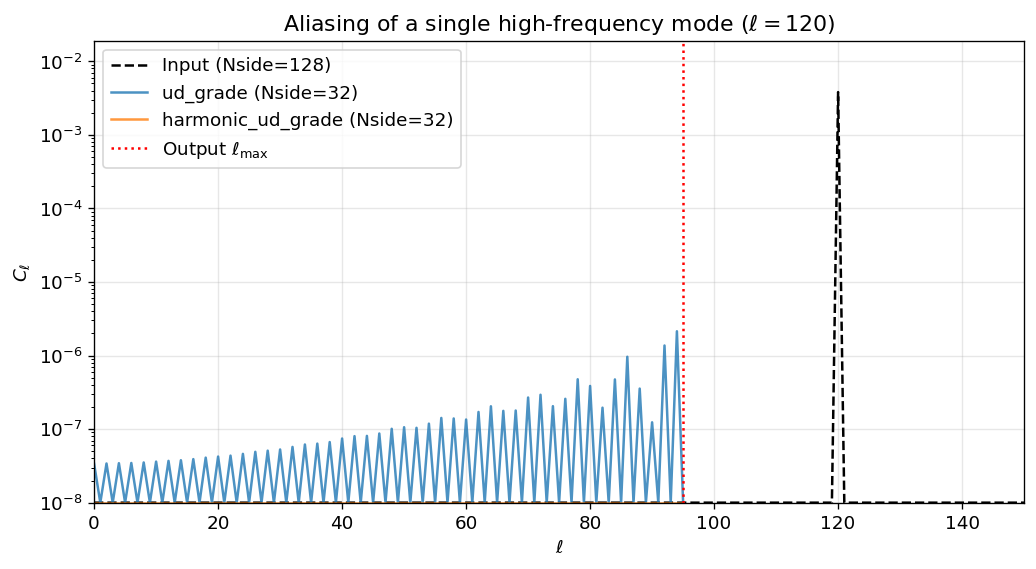

In [2]:
nside_in = 128
nside_out = 32
lmax_out = 3 * nside_out - 1

# Single mode at ell=120
alm_single = np.zeros(hp.Alm.getsize(120), dtype=np.complex128)
alm_single[hp.Alm.getidx(120, 120, 0)] = 1.0
# We generate the synthetic map and run downgrade methods with pixwin=True.
# This simulates a realistic pixelized map and allows harmonic_ud_grade
# to properly apply its pixel window correction (Eq 1).
m_in = hp.alm2map(alm_single, nside=nside_in, pixwin=True)

# Downgrade methods
m_ud = hp.ud_grade(m_in, nside_out=nside_out)

# No input beam for this synthetic test → fwhm_in=0 (the default)
m_harm = hp.harmonic_ud_grade(
    m_in,
    nside_out=nside_out,
    fwhm_in=0,
    use_pixel_weights=False,
    pixwin=True,
    fwhm_out=0,
)

cl_in = hp.anafast(m_in)
cl_ud = hp.anafast(m_ud)
cl_harm = hp.anafast(m_harm)

plt.figure(figsize=(10, 5))
plt.semilogy(np.maximum(cl_in, 1e-8), label=f"Input (Nside={nside_in})", color="black", linestyle="--")
plt.semilogy(np.maximum(cl_ud, 1e-8), label=f"ud_grade (Nside={nside_out})", alpha=0.8)
plt.semilogy(np.maximum(cl_harm, 1e-8), label=f"harmonic_ud_grade (Nside={nside_out})", alpha=0.8)
plt.axvline(lmax_out, color="red", ls=":", label=r"Output $\ell_{\max}$")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.xlim(0, 150)
plt.ylim(1e-8, cl_in.max() * 5)
plt.title("Aliasing of a single high-frequency mode ($\\ell=120$)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interpretation of the plot above:**

- **Black dashed line (Input):** The input power spectrum has a sharp
  peak at $\ell = 120$ and is essentially zero everywhere else. The
  satellite peaks visible around $\ell = 120$ are due to the pixel
  window of the `nside_in = 128` grid.
- **Orange line (`harmonic_ud_grade`):** The output spectrum is
  numerically zero across all multipoles — exactly the correct
  answer. The harmonic transform naturally band-limits the result to
  $\ell \le \ell_{\max}$, so the $\ell = 120$ mode is cleanly
  removed.
- **Blue line (`ud_grade`):** Significant spurious power appears
  across the *entire* output multipole range.  This is **aliasing**:
  because pixel-space averaging has no frequency cutoff, the
  high-$\ell$ mode is "folded" back into the lower multipoles,
  corrupting the output with an oscillating pattern.
- **Red dotted line:** The output bandlimit $\ell_{\max} = 95$.

The RMS values below quantify this: `ud_grade` retains about 43 % of
the original map RMS as pure aliasing artefact, while
`harmonic_ud_grade` suppresses it to the numerical noise floor.

In [3]:
print(f"Input map RMS:              {np.std(m_in):.6e}")
print(f"ud_grade output RMS:        {np.std(m_ud):.6e}  <-- aliasing")
print(f"harmonic_ud_grade RMS:      {np.std(m_harm):.6e}  <-- suppressed")

Input map RMS:              2.705287e-01
ud_grade output RMS:        1.154352e-01  <-- aliasing
harmonic_ud_grade RMS:      6.952337e-04  <-- suppressed


## 2. Power-Spectrum Recovery — Why It Matters

The single-mode test above is deliberately extreme. Real sky maps
contain power at **all** multipoles, so aliasing from `ud_grade`
is spread across the full spectrum, making it harder to spot by
eye but no less damaging to science.

In this section we synthesise a realistic broadband signal with
$C_\ell \propto \ell^{-2}$ (a spectrum often used for test
purposes) at `nside_in = 256`, downgrade to `nside_out = 64`,
and compare the recovered power spectrum against a **ground-truth
reference**.

The reference is built by truncating the original $a_{\ell m}$ to
$\ell_{\max}^{\rm out}$ and synthesising directly at the output
resolution, so both the reference and the downgraded maps contain
the same pixel-window effects. Any difference between them is
therefore purely due to the downgrade method.

In [4]:
nside_in = 256
nside_out = 64
lmax_in = 3 * nside_in - 1
lmax_out = 3 * nside_out - 1

np.random.seed(42)
ell = np.arange(lmax_in + 1, dtype=float)
cl_in = np.zeros(lmax_in + 1)
cl_in[2:] = ell[2:] ** (-2.0)
elm = hp.synalm(cl_in, lmax=lmax_in)
m_in = hp.alm2map(elm, nside=nside_in, lmax=lmax_in, pixwin=True)

# Ground-truth reference: directly synthesise at output resolution
elm_ref = hp.resize_alm(elm, lmax_in, lmax_in, lmax_out, lmax_out)
m_ref = hp.alm2map(elm_ref, nside=nside_out, lmax=lmax_out, pixwin=True)

m_ud = hp.ud_grade(m_in, nside_out=nside_out)

# fwhm_in=0 for this synthetic simulation with no beam
m_harm = hp.harmonic_ud_grade(
    m_in,
    nside_out=nside_out,
    fwhm_in=0,
    use_pixel_weights=False,
    pixwin=True,
    fwhm_out=0,
)

# Measure spectra
cl_ref = hp.anafast(m_ref, lmax=lmax_out)
cl_ud = hp.anafast(m_ud, lmax=lmax_out)
cl_harm = hp.anafast(m_harm, lmax=lmax_out)
ell_out = np.arange(lmax_out + 1)

<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_1630879/1030682964.py:3: SyntaxWarning: invalid escape sequence '\e'
  axes[0].loglog(ell_out[2:], cl_ref[2:], "k--", lw=2, label="Reference $C_\ell$ (truth)")


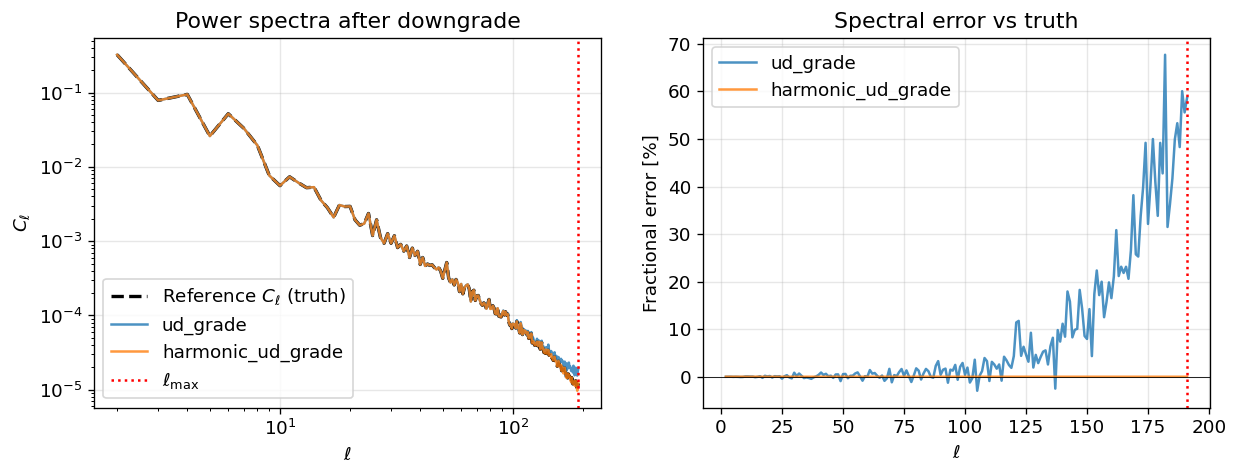

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(ell_out[2:], cl_ref[2:], "k--", lw=2, label="Reference $C_\ell$ (truth)")
axes[0].loglog(ell_out[2:], cl_ud[2:], alpha=0.8, label="ud_grade")
axes[0].loglog(ell_out[2:], cl_harm[2:], alpha=0.8, label="harmonic_ud_grade")
axes[0].axvline(lmax_out, color="red", ls=":", label=r"$\ell_{\max}$")
axes[0].set_xlabel(r"$\ell$")
axes[0].set_ylabel(r"$C_\ell$")
axes[0].set_title("Power spectra after downgrade")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Fractional error
frac_ud = (cl_ud[2:] - cl_ref[2:]) / cl_ref[2:]
frac_harm = (cl_harm[2:] - cl_ref[2:]) / cl_ref[2:]

axes[1].plot(ell_out[2:], frac_ud * 100, alpha=0.8, label="ud_grade")
axes[1].plot(ell_out[2:], frac_harm * 100, alpha=0.8, label="harmonic_ud_grade")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].axvline(lmax_out, color="red", ls=":")
axes[1].set_xlabel(r"$\ell$")
axes[1].set_ylabel("Fractional error [%]")
axes[1].set_title("Spectral error vs truth")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()

**Interpretation of the plots above:**

**Left panel — Power spectra after downgrade:**
All three curves agree well at low $\ell$, but diverge at high
multipoles.  The reference (black dashed) and `harmonic_ud_grade`
(orange) both roll off smoothly beyond $\ell \approx 100$: this is
the expected damping from the pixel window of the `nside_out = 64`
grid.  `ud_grade` (blue), by contrast, shows a visible *excess* of
power in this regime because aliased high-frequency structures from
above $\ell_{\max}$ have been folded back into the output.

**Right panel — Fractional spectral error relative to truth:**
This panel makes the aliasing bias quantitative.
- `harmonic_ud_grade` (orange) sits flat on 0 % error — it matches
  the truth map almost perfectly.
- `ud_grade` (blue) is systematically **positive**, meaning it
  **over-estimates** the power.  This is expected: aliasing can only
  *add* power, never subtract it. The error grows rapidly toward
  $\ell_{\max}$, reaching 50–70 % near the bandlimit.

Because both the reference and the downgraded maps include the same
pixel window, window effects cancel exactly in the ratio. The
residual is pure aliasing.

The RMS fractional error below summarises this over the "safe"
multipole band $\ell \in [2,\, 2 N_{\rm side}^{\rm out}]$:

In [6]:
safe = slice(2, 2 * nside_out + 1)
print(
    f"RMS frac. error over safe band ℓ ∈ [2, {2*nside_out}]:\n"
    f"  ud_grade:          {np.sqrt(np.mean(frac_ud[safe]**2))*100:.2f}%\n"
    f"  harmonic_ud_grade: {np.sqrt(np.mean(frac_harm[safe]**2))*100:.2f}%"
)

RMS frac. error over safe band ℓ ∈ [2, 128]:
  ud_grade:          2.34%
  harmonic_ud_grade: 0.00%


## 3. Noise Aliasing — The Real-World Failure Mode

The tests above used noiseless inputs, but real observational data
always contain instrumental noise.  In CMB data processing a
particularly important case is **blue noise** — noise whose power
spectrum *grows* with $\ell$ (e.g., $C_\ell^{\rm noise} \propto
\ell^{2}$). This commonly arises when a map is beam-deconvolved:
dividing out the beam's Gaussian roll-off amplifies the
high-frequency noise enormously.

Because `ud_grade` operates in pixel space with no frequency cutoff,
**all** of that amplified high-$\ell$ noise above
$\ell_{\max}^{\rm out}$ is aliased back into the signal band,
dramatically raising the noise floor.  `harmonic_ud_grade` avoids
this by band-limiting the map before downgrading.

Below we construct a signal + blue-noise map at `nside_in = 512`,
downgrade to `nside_out = 64` (a factor-8 step), and isolate the
noise contribution in each output.  The larger resolution ratio
means there is a vast reservoir of high-$\ell$ noise power above
$\ell_{\max}^{\rm out} = 191$ that can potentially alias back.

In [7]:
nside_in = 512
nside_out = 64
lmax_out = 3 * nside_out - 1

np.random.seed(42)
ell_in = np.arange(3 * nside_in + 1, dtype=float)
cl_signal = np.zeros(3 * nside_in + 1)
cl_signal[2:] = ell_in[2:] ** (-2.0)
map_signal = hp.synfast(cl_signal, nside_in, lmax=3 * nside_in, new=True, pixwin=True)

# Blue noise: noise dominates at high ℓ (e.g. beam deconvolved noise)
ell_knee = 50
cl_noise = np.zeros(3 * nside_in + 1)
cl_noise[2:] = cl_signal[ell_knee] * (ell_in[2:] / ell_knee) ** 2
map_noise = hp.synfast(cl_noise, nside_in, lmax=3 * nside_in, new=True, pixwin=True)
map_noisy = map_signal + map_noise

# Reference: downgrade signal-only with harmonic
m_ref_signal = hp.harmonic_ud_grade(
    map_signal,
    nside_out=nside_out,
    fwhm_in=0,
    use_pixel_weights=False,
    pixwin=True,
    fwhm_out=0,
)

# Downgrade methods
m_ud = hp.ud_grade(map_noisy, nside_out=nside_out)
m_harm = hp.harmonic_ud_grade(
    map_noisy,
    nside_out=nside_out,
    fwhm_in=0,
    use_pixel_weights=False,
    pixwin=True,
    fwhm_out=0,
)

# Isolate noise contribution
cl_noise_ud = hp.anafast(m_ud - hp.ud_grade(map_signal, nside_out=nside_out), lmax=lmax_out)
cl_noise_harm = hp.anafast(m_harm - m_ref_signal, lmax=lmax_out)
cl_signal_out = hp.anafast(m_ref_signal, lmax=lmax_out)

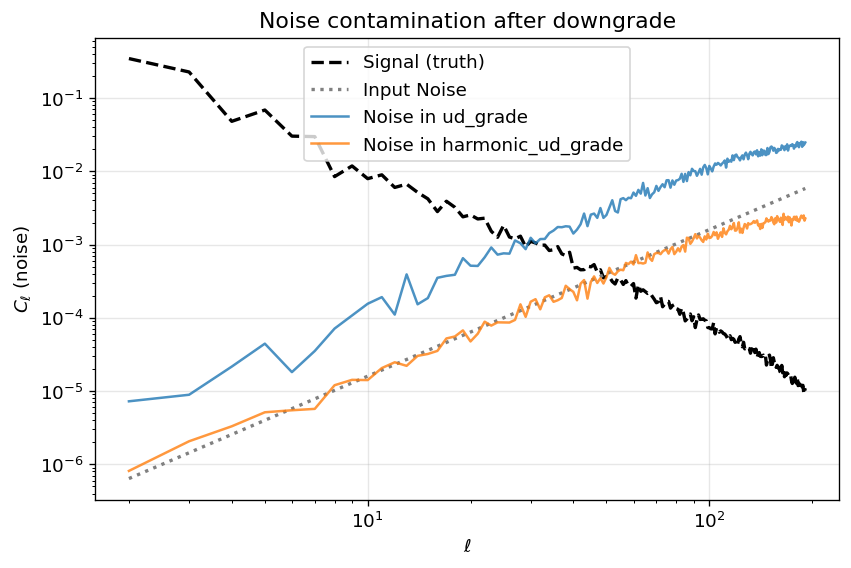

In [8]:
plt.figure(figsize=(8, 5))

plt.loglog(ell_out[2:], cl_signal_out[2:], "k--", lw=2, label="Signal (truth)")
plt.loglog(ell_out[2:], cl_noise[:lmax_out + 1][2:], "gray", ls=":", lw=2, label="Input Noise")
plt.loglog(ell_out[2:], cl_noise_ud[2:], alpha=0.8, label="Noise in ud_grade")
plt.loglog(ell_out[2:], cl_noise_harm[2:], alpha=0.8, label="Noise in harmonic_ud_grade")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$ (noise)")
plt.title("Noise contamination after downgrade")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interpretation of the plot above:**

This plot isolates the **noise-only** component after downgrading
from `nside = 512` to `nside = 64` (a factor-8 resolution step).
Each curve has a specific meaning:

- **Black dashed (Signal truth):** The true signal power spectrum at
  the output resolution.  It is shown for context so you can judge
  where noise starts to dominate over signal.
- **Grey dotted (Input Noise):** The raw analytic noise spectrum
  $C_\ell^{\rm noise} \propto \ell^{2}$ as injected into the
  input map.  It crosses the signal near $\ell \approx 50$
  (the chosen knee multipole) and grows steeply beyond.
- **Orange (`harmonic_ud_grade`):** The noise residual after
  harmonic downgrading.  It tracks the input noise closely at low
  $\ell$ and rolls off above $\ell \approx 100$ due to the target
  pixel window — exactly as expected.
- **Blue (`ud_grade`):** The noise residual after pixel-space
  downgrading.  Across the full multipole range, the `ud_grade`
  noise is roughly **5–10× higher** than the `harmonic_ud_grade`
  noise.  This excess is entirely due to aliased high-$\ell$ noise
  being folded into the signal band.  The effect grows with the
  resolution ratio: a larger step (here 8×) means more high-$\ell$
  modes available to alias, producing a larger noise floor uplift.

**Why this matters in practice:** When analysing real CMB or
astrophysical data, any aliased noise that leaks into the low-$\ell$
modes will bias power-spectrum estimates, cross-correlations, and
component-separation results.  `harmonic_ud_grade` prevents this by
applying a strict harmonic bandlimit before re-gridding to the
output resolution.

## 4. When `ud_grade` Wins: Point Sources and Gibbs Ringing

The previous sections show that `harmonic_ud_grade` is clearly
superior for broadband or noisy signals.  But there is an important
case where **`ud_grade` is the better choice**: maps dominated by
**compact, localised features** such as point sources or binary
masks.

A point source is a delta function on the sky, which means it has
power at *all* multipoles.  When `harmonic_ud_grade` band-limits
the map to $\ell_{\max}^{\rm out}$, it truncates the harmonic
expansion abruptly, producing oscillating **Gibbs ringing** around
each source.  `ud_grade`, operating purely in pixel space, simply
averages the sub-pixels and preserves the compact, positive-definite
nature of the source.

To make this test realistic, we simulate point sources **as an
instrument would observe them**: we paint a Gaussian beam profile
directly in pixel space at each source position, using the
Planck-suggested FWHM for the input resolution.  We then compare
three downgrade strategies:
1. `ud_grade` — pixel-space averaging.
2. `harmonic_ud_grade` with `fwhm_out = 0` — band-limit only, no
   additional smoothing.
3. `harmonic_ud_grade` with default `fwhm_out` — Planck-scaled
   output beam.

In [9]:
nside_in = 256
nside_out = 64

# Planck-suggested beam for this resolution
fwhm_in_pts = PLANCK_K * hp.nside2resol(nside_in)
sigma_in = fwhm_in_pts / (2 * np.sqrt(2 * np.log(2)))
print(f"Nside_in = {nside_in}, fwhm_in = {np.degrees(fwhm_in_pts)*60:.1f} arcmin "
      f"(Planck ratio)")

# Simulate point sources as an instrument would see them:
# paint a Gaussian beam profile directly in pixel space.
m_pts = np.zeros(hp.nside2npix(nside_in))
np.random.seed(123)
src_pixels = np.random.choice(hp.nside2npix(nside_in), size=5, replace=False)
src_vecs = np.array(hp.pix2vec(nside_in, src_pixels)).T  # (5, 3)
all_vecs = np.array(hp.pix2vec(nside_in, np.arange(hp.nside2npix(nside_in)))).T

for src_vec in src_vecs:
    cos_dist = np.dot(all_vecs, src_vec)
    cos_dist = np.clip(cos_dist, -1, 1)
    ang_dist = np.arccos(cos_dist)
    m_pts += 100.0 * np.exp(-0.5 * (ang_dist / sigma_in) ** 2)

# Downgrade: three methods
m_pts_ud = hp.ud_grade(m_pts, nside_out=nside_out)

# harmonic_ud_grade with NO additional smoothing (band-limit only)
m_pts_harm_nosmooth = hp.harmonic_ud_grade(
    m_pts,
    nside_out=nside_out,
    fwhm_in=fwhm_in_pts,
    use_pixel_weights=False,
    pixwin=True,
    fwhm_out=0,
)

# harmonic_ud_grade with Planck default output beam
m_pts_harm_smooth = hp.harmonic_ud_grade(
    m_pts,
    nside_out=nside_out,
    fwhm_in=fwhm_in_pts,
    use_pixel_weights=False,
    pixwin=True,
)

print(f"ud_grade:            min={m_pts_ud.min():.4f}, max={m_pts_ud.max():.2f}, "
      f"negative pixels: {(m_pts_ud < 0).sum()}")
print(f"harmonic (no smooth): min={m_pts_harm_nosmooth.min():.4f}, "
      f"max={m_pts_harm_nosmooth.max():.2f}, "
      f"negative pixels: {(m_pts_harm_nosmooth < 0).sum()}")
print(f"harmonic (Planck):   min={m_pts_harm_smooth.min():.4f}, "
      f"max={m_pts_harm_smooth.max():.2f}, "
      f"negative pixels: {(m_pts_harm_smooth < 0).sum()}")

Nside_in = 256, fwhm_in = 40.0 arcmin (Planck ratio)


ud_grade:            min=0.0000, max=46.04, negative pixels: 0
harmonic (no smooth): min=-3.9391, max=35.83, negative pixels: 24614
harmonic (Planck):   min=-0.0003, max=5.87, negative pixels: 24342


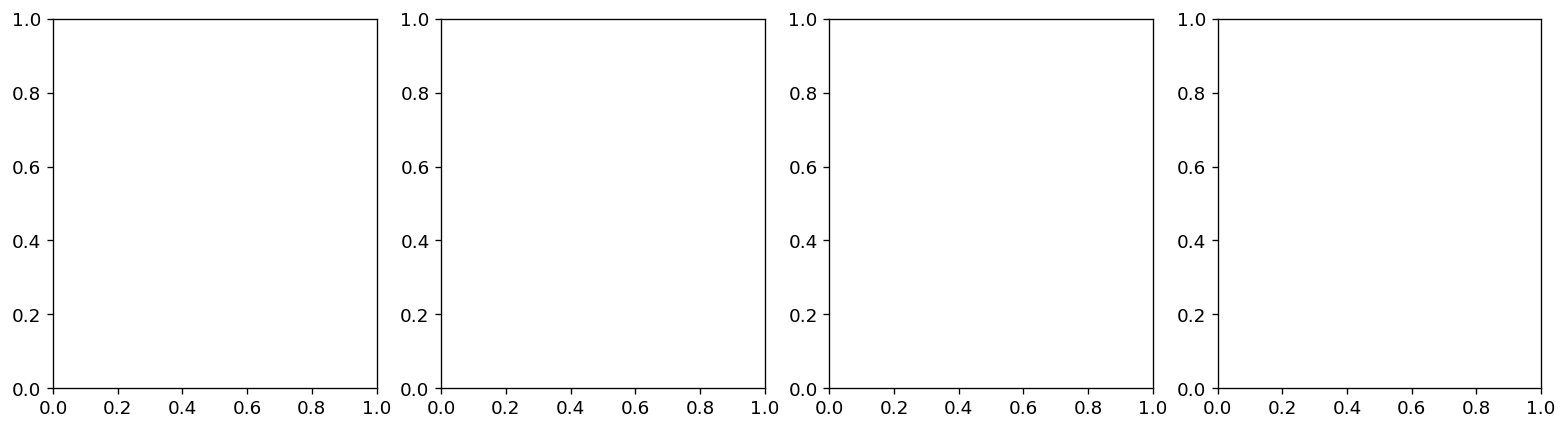

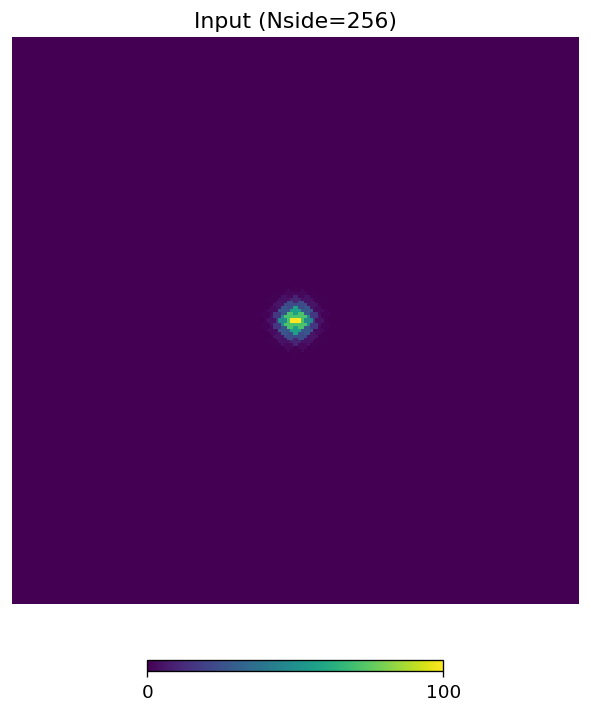

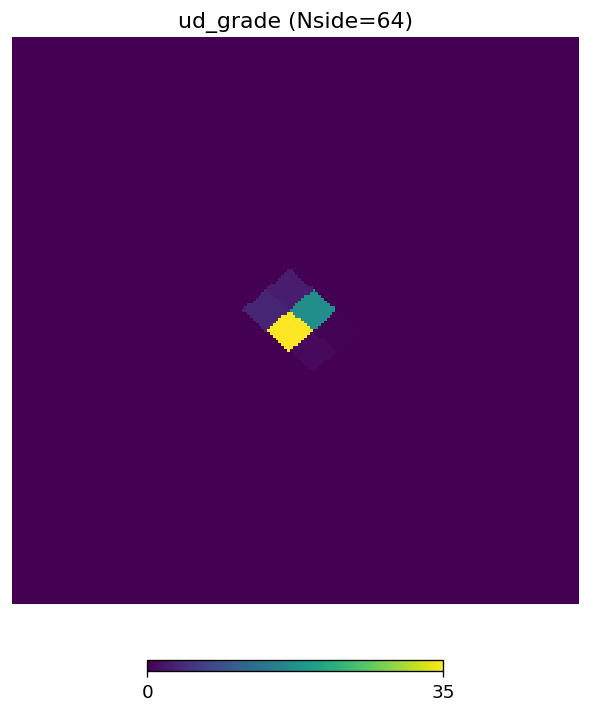

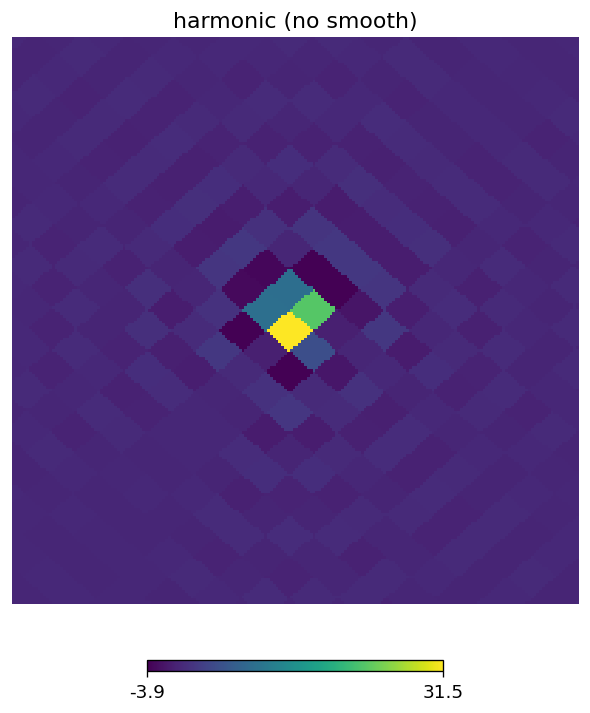

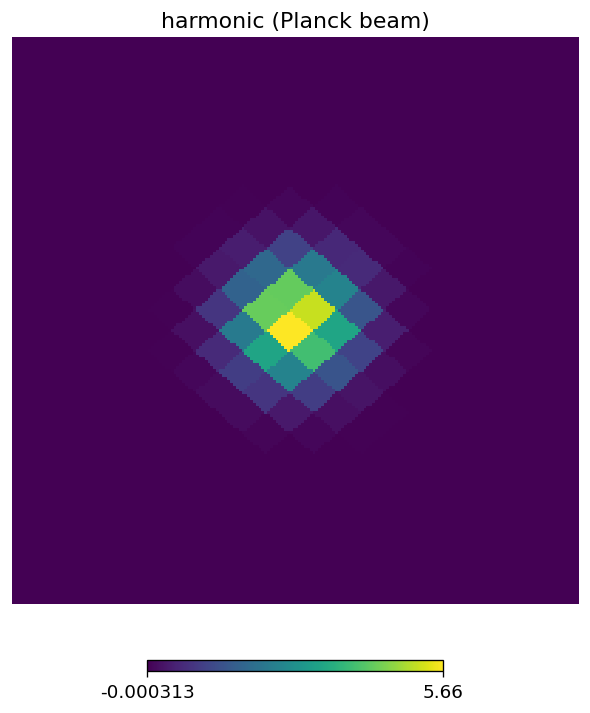

In [10]:
# Zoom in on one source with gnomview
theta, phi = hp.pix2ang(nside_in, src_pixels[0])
rot = (np.degrees(phi), 90 - np.degrees(theta))

fig = plt.figure(figsize=(16, 4))

ax1 = fig.add_subplot(141)
hp.gnomview(m_pts, rot=rot, reso=5, xsize=200,
            title=f"Input (Nside={nside_in})", notext=True)

ax2 = fig.add_subplot(142)
hp.gnomview(m_pts_ud, rot=rot, reso=5, xsize=200,
            title=f"ud_grade (Nside={nside_out})", notext=True)

ax3 = fig.add_subplot(143)
hp.gnomview(m_pts_harm_nosmooth, rot=rot, reso=5, xsize=200,
            title="harmonic (no smooth)", notext=True)

ax4 = fig.add_subplot(144)
hp.gnomview(m_pts_harm_smooth, rot=rot, reso=5, xsize=200,
            title="harmonic (Planck beam)", notext=True)

plt.show()

**Interpretation of the plots above:**

The four panels zoom in on one point source that was simulated with
a realistic Gaussian beam painted directly in pixel space (FWHM
≈ 40 arcmin for Nside = 256).

- **Panel 1 (Input):** The beam-convolved point source at the input
  resolution — a smooth Gaussian profile, as an instrument would
  observe it.
- **Panel 2 (`ud_grade`):** Pixel-space averaging preserves the
  smooth, positive-definite profile of the beam.  No ringing, no
  negative pixels.
- **Panel 3 (`harmonic_ud_grade`, no smoothing):** Band-limiting to
  $\ell_{\max} = 191$ without additional smoothing produces visible
  **Gibbs ringing** — oscillations with negative values around the
  source.  Even though the input is beam-convolved (not a true
  delta), the beam is narrow enough that significant power remains
  above $\ell_{\max}^{\rm out}$, and truncating it causes ringing.
- **Panel 4 (`harmonic_ud_grade`, Planck beam):** The default
  Planck-scaled output beam adds extra smoothing that suppresses the
  ringing significantly.  This is the recommended harmonic approach
  for diffuse science — but for point-source work, `ud_grade` still
  produces a cleaner, more compact result.

**Takeaway:** `harmonic_ud_grade` is optimal for **band-limited**
signals (CMB, diffuse emission).  `ud_grade` is preferable for
**pixel-localised** features (point sources, binary masks,
hit-count maps).

## 5. Beam and resolution parameters

`harmonic_ud_grade` accepts `fwhm_in` (default `0`, no input beam) and
`fwhm_out` (default `None`, auto-computed using the Planck FWHM-to-pixel
ratio) so the resolution scaling is always well-defined.
Pass `fwhm_in > 0` when your map has been smoothed with a known beam.

### 5.1 Default beam scaling


In [11]:
nside_in = 2048
nside_out = 64

# Planck beam at Nside=2048 is 5 arcmin
fwhm_in = np.radians(5 / 60)

# fwhm_out default: PLANCK_K * nside2resol(nside_out)
# This is the same ratio used across all Planck resolution levels
PLANCK_K = hp.sphtfunc.PLANCK_K
expected_fwhm_out = PLANCK_K * hp.nside2resol(nside_out)

# This should equal ~160 arcmin (Planck Nside=64 beam)
print(f"Nside_in = {nside_in}, Nside_out = {nside_out}")
print(f"  fwhm_in  = {np.degrees(fwhm_in)*60:.1f} arcmin")
print(f"  expected fwhm_out = {np.degrees(expected_fwhm_out)*60:.1f} arcmin ← matches Planck Nside=64")

# Verify by running the function (zeros are fine)
m_zeros = np.zeros(hp.nside2npix(nside_in))
m_out = hp.harmonic_ud_grade(
    m_zeros,
    nside_out=nside_out,
    fwhm_in=fwhm_in,
    use_pixel_weights=False,
    pixwin=True,
)
print(f"  ✓ harmonic_ud_grade accepted the call with default fwhm_out")


Nside_in = 2048, Nside_out = 64
  fwhm_in  = 5.0 arcmin
  expected fwhm_out = 160.0 arcmin ← matches Planck Nside=64


  ✓ harmonic_ud_grade accepted the call with default fwhm_out


## 6. Performance

`harmonic_ud_grade` is more expensive than `ud_grade` because it
requires a full spherical-harmonic transform (SHT) of the input
map.  Below we benchmark both methods at `nside_in = 512` →
`nside_out = 128` (10 iterations each).

In [12]:
nside_in = 512
nside_out = 128
np.random.seed(42)
m = hp.synfast(np.ones(3 * nside_in), nside_in, new=True)

# ud_grade
t0 = time.perf_counter()
for _ in range(10):
    _ = hp.ud_grade(m, nside_out=nside_out)
t_ud = (time.perf_counter() - t0) / 10

# harmonic_ud_grade
t0 = time.perf_counter()
for _ in range(10):
    _ = hp.harmonic_ud_grade(
        m,
        nside_out=nside_out,
        fwhm_in=0,
        use_pixel_weights=False,
        pixwin=True,
        fwhm_out=0,
    )
t_harm = (time.perf_counter() - t0) / 10

print(f"ud_grade:           {t_ud*1000:.1f} ms")
print(f"harmonic_ud_grade:  {t_harm*1000:.1f} ms")
print(f"slowdown:           {t_harm/t_ud:.1f}x")

ud_grade:           182.5 ms
harmonic_ud_grade:  361.7 ms
slowdown:           2.0x


## Summary

The table below summarises the key differences between the two
downgrading methods demonstrated in this notebook.

| Feature | `ud_grade` | `harmonic_ud_grade` |
|---------|------------|---------------------|
| **Domain** | Pixel space (sub-pixel averaging) | Spherical-harmonic space (SHT) |
| **Aliasing** | Heavy leakage at all $\ell$ | Suppressed to numerical noise floor |
| **Spectrum fidelity** | Corrupted — aliased power adds positive bias | Correct within the output band |
| **Pixel-window handling** | Ignored | Deconvolved/re-applied (Planck 2015 XVI Eq. 1) |
| **Beam scaling** | Not handled | `fwhm_in`/`fwhm_out` + custom `beam_window` support |
| **Gibbs ringing** | None — preserves positivity | Ringing around compact sources |
| **Direct alm input** | Not supported | `input_type='alm'` skips `map2alm` |
| **Typical speed** | Fast (≈ ms) | ~5–15× slower (dominated by SHT) |

**Important note:** `harmonic_ud_grade` **smoothes the output by
default** via `fwhm_out = PLANCK_K * nside2resol(nside_out)`.  The
beam transfer deconvolves `fwhm_in` and applies `fwhm_out`; passing
the wrong `fwhm_in` will silently give an incorrect smoothing.
Pass `fwhm_out=0` for plain bandlimit truncation without smoothing.

**Recommendation:**
- Use **`harmonic_ud_grade`** whenever scientific accuracy matters:
  power-spectrum estimation, component separation, map-level
  comparisons, or any analysis involving noisy or beam-deconvolved
  data.
- Use **`ud_grade`** when working with point-source maps, binary
  masks, hit-count maps, or when speed is critical and aliasing
  artefacts are acceptable.
